# Momentum & Value Strategy Backtester — Phase 4: Long-Short Momentum

**Strategy:** the same 12-1 momentum signal as Phase 1, now used in *both* directions:
**long the 50 highest-momentum names AND short the 50 lowest-momentum names**, equal-weighted
within each book, monthly rebalanced, on the point-in-time S&P 500 over the same 2012–2026
window. Everything shared with Phase 1 (signal, universe, window, cadence, benchmark, cost
assumption) is deliberately identical, so any difference in results comes from the long-short
*structure*, not from incidental implementation differences.

**What "shorting" actually is.** Buying a stock profits when it rises. *Short selling* is the
mirror image: you **borrow** shares (from a broker's securities-lending pool), **sell them
immediately** at today's price, and later **buy them back** to return to the lender. If the
price fell in between, you buy back cheaper than you sold — the difference is profit. Two
things about that mechanic matter for everything below:

1. **It isn't free.** The share lender charges an annualized *borrow fee* for as long as the
   position is open — a carrying cost with no long-only equivalent, modeled explicitly here.
2. **Losses are unbounded.** A long position can lose at most 100% (the stock goes to zero).
   A shorted stock can rise without limit, and every dollar it rises is a dollar lost. This
   asymmetry is the defining risk of the strategy and comes up repeatedly below.

**Why short the losers at all?** The momentum literature's claim is symmetric: recent winners
tend to keep winning *and recent losers tend to keep losing*. Phase 1 only harvested the first
half. If the second half is real, the bottom of the ranking is a return source too — and the
classic academic momentum factor ("winners minus losers", WML) is defined exactly this way.

**The two headline variants** (same stock picks, different position sizes — both are shown
because they answer different questions):

- **Dollar-neutral (1.0 / 1.0):** $1 long and $1 short per $1 of capital. Broad market moves
  hit both books roughly equally and cancel, leaving (approximately) the *pure momentum bet*,
  with little stock-market exposure. This is the academic factor, and the cleanest test of
  whether the momentum signal itself carries a two-sided premium.
- **130/30 (1.3 / 0.3):** $1.30 long, $0.30 short — net exposure 1.0, like an ordinary index
  fund, but with a small short book expressing negative views. This is a structure real funds
  actually sell, and the fairer head-to-head against long-only momentum and SPY.

**What is a "momentum crash"?** The strategy's known failure mode. When a bear market turns,
the most beaten-down stocks (the short book, by construction) can rally violently — in 2009,
the academic momentum factor lost most of its value in a few months, driven almost entirely by
the short side. Worth knowing before looking at any Sharpe ratio below: this window
(2012–2026) does **not** contain a 2009-scale reversal, so the headline numbers show the
strategy in ordinary weather (see Limitations).

**Costs.** Each book pays the same round-trip transaction cost as Phase 1 (2 × turnover ×
10bps one-way, per book, scaled by the book's size), and the short book additionally pays a
blended 30bps/year borrow fee, charged monthly. Consistent with the project-wide 0% risk-free
assumption, **no interest is earned on the short-sale proceeds and no financing cost is charged
on the 130% variant's extra leverage** — stated plainly here and in Limitations, and roughly
offsetting only in a low-rate world.

**No parameters here were tuned to this dataset.** The signal, book sizes, and rebalance
cadence are Phase 1's textbook values; the two exposure pairs are the standard academic and
industry structures, chosen before running anything; 30bps borrow is a typical large-cap
general-collateral rate. The robustness appendix reruns nearby cost/borrow/exposure choices to
show the qualitative picture isn't a cherry-picked cell of a grid.

## 1. Setup

In [1]:
import sys
from pathlib import Path
from dataclasses import replace

import pandas as pd
import matplotlib.pyplot as plt

# Allow `import src.*` when this notebook is run from the notebooks/ directory.
sys.path.append(str(Path("..").resolve()))

from src.config import DEFAULT_CONFIG, DEFAULT_LONG_SHORT_CONFIG
from src.data_layer.constituents import load_constituents_table, get_membership
from src.data_layer.prices import get_prices
from src.strategy.momentum import compute_momentum_signal
from src.backtest.engine import run_backtest, compute_warmup_start
from src.backtest.long_short_engine import (
    run_long_short_backtest,
    compute_long_short_benchmark_result,
)
from src.evaluation.metrics import (
    summary_table, cagr, annualized_vol, sharpe_ratio, max_drawdown,
)
from src.evaluation.plots import plot_drawdown

# The two headline variants. Dollar-neutral IS the default config; 130/30
# differs ONLY in its exposures, so both variants pick identical stocks and
# any difference in results is purely the exposure arithmetic.
dollar_neutral_config = DEFAULT_LONG_SHORT_CONFIG          # long 1.0 / short 1.0
config_130_30 = replace(DEFAULT_LONG_SHORT_CONFIG, long_exposure=1.3, short_exposure=0.3)

print(dollar_neutral_config)

LongShortBacktestConfig(start_date='2012-01-01', end_date='2026-06-30', lookback_months=12, skip_months=1, rebalance_freq='ME', top_n=50, bottom_n=50, long_exposure=1.0, short_exposure=1.0, benchmark_ticker='SPY', risk_free_rate=0.0, one_way_cost_bps=10.0, borrow_fee_annual_bps=30.0, price_outlier_threshold=0.5, cache_dir=WindowsPath('C:/Users/arwga/Developer/ClaudeProjects/Trading/MomentumValueStrategy/data/cache'), constituents_url='https://raw.githubusercontent.com/fja05680/sp500/master/S%26P%20500%20Historical%20Components%20%26%20Changes%20(Updated).csv')


## 2. The two books, illustrated

One momentum ranking, read from both ends: the long book takes the top 50, the short book the
bottom 50. The short side is **not** a separate signal — it's the same 12-1 calculation Phase 1
uses (and the same code: `compute_momentum_signal`), so the two books can never disagree about
what "momentum" means on a given date. Below, the extremes of the ranking on the first
rebalance date, to make both books concrete.

In [2]:
config = dollar_neutral_config

constituents_table = load_constituents_table(cache_dir=config.cache_dir, url=config.constituents_url)
requested_rebalance_dates = pd.date_range(config.start_date, config.end_date, freq=config.rebalance_freq)

all_tickers = set()
for d in requested_rebalance_dates:
    all_tickers.update(get_membership(d, constituents_table))
all_tickers.add(config.benchmark_ticker)

# Same 13-month signal warmup as Phase 1 (see notebook 01, section 3).
warmup_start = compute_warmup_start(config.start_date, config.lookback_months, config.skip_months)
daily_prices, failed_tickers = get_prices(sorted(all_tickers), warmup_start, config.end_date, cache_dir=config.cache_dir)
print(f"Prices for {daily_prices.shape[1]} tickers ({len(failed_tickers)} failed - the known coverage gap discussed in notebook 01)")

month_end_prices = daily_prices.resample(config.rebalance_freq).last()
example_date = month_end_prices.index[month_end_prices.index >= pd.Timestamp(config.start_date)][0]

scores = compute_momentum_signal(month_end_prices, example_date, config.lookback_months, config.skip_months)
eligible = scores[scores.index.isin(get_membership(example_date, constituents_table))]

print(f"\nMomentum ranking as of {example_date.date()} ({len(eligible)} scored constituents):")
print("\nTop 5 (long book candidates - strongest 12-1 momentum):")
print(eligible.sort_values(ascending=False).head(5))
print("\nBottom 5 (SHORT book candidates - weakest 12-1 momentum):")
print(eligible.sort_values(ascending=True).head(5))

$BXLT: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$CPGX: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$ANRZQ: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$FRX: possibly delisted; no timezone found


$BIG: possibly delisted; no timezone found


...

$VAR: possibly delisted; no timezone found



19 Failed downloads:


['WFM', 'TWC']: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


['VIAB', 'WRK', 'WIN', 'WLTW', 'TWTR', 'UTX', 'WBA', 'XLNX', 'TSS', 'X', 'WYND', 'XEC', 'WCG', 'VIAC', 'XL', 'WPX', 'VAR']: possibly delisted; no timezone found


Prices for 642 tickers (169 failed - the known coverage gap discussed in notebook 01)

Momentum ranking as of 2012-01-31 (343 scored constituents):

Top 5 (long book candidates - strongest 12-1 momentum):
TIE     370.352778
BIIB      0.680923
DLTR      0.643140
MA        0.578758
VFC       0.572597
dtype: float64

Bottom 5 (SHORT book candidates - weakest 12-1 momentum):
FSLR   -0.781602
NFLX   -0.676336
GR     -0.642857
BAC    -0.593110
EP     -0.571429
dtype: float64


## 3. Full backtest: both variants

Per-book diagnostics are printed alongside the run, because the two books' data problems bias
results in **opposite** directions (a dropped delisting flatters the long book but understates
the short book's profit; an excluded implausible gain flatters the short book) — so they are
counted separately per book rather than lumped together. See Limitations for the full
discussion. Turnover is also tracked per book, because each book pays trading costs on its own
churn — the diagnostics below show whether the bottom of the ranking actually turns over
faster than the top, rather than assuming it.

In [3]:
dollar_neutral_result = run_long_short_backtest(dollar_neutral_config)
result_130_30 = run_long_short_backtest(config_130_30)

for name, res in [("Dollar-neutral (1.0/1.0)", dollar_neutral_result),
                  ("130/30 (1.3/0.3)", result_130_30)]:
    print(f"--- {name} ---")
    print(f"Rebalances: {len(res.net_returns)}")
    print(f"Avg monthly turnover:   long book {res.long_turnover_history.mean():.1%}, "
          f"short book {res.short_turnover_history.mean():.1%}")
    print(f"Missing forward prices: long book {res.long_missing_forward_price_count}, "
          f"short book {res.short_missing_forward_price_count}")
    print(f"Extreme-return exclusions (>300% underlying monthly gain, treated as vendor glitches): "
          f"long book {res.long_extreme_return_count}, short book {res.short_extreme_return_count}")
    print()

$ANRZQ: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$CPGX: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$BXLT: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$COG: possibly delisted; no timezone found


$CTLT: possibly delisted; no timezone found


...

$UTX: possibly delisted; no timezone found



19 Failed downloads:


['TWC', 'WFM']: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


['WCG', 'XL', 'XLNX', 'X', 'WBA', 'WRK', 'XEC', 'WLTW', 'TWTR', 'WPX', 'VAR', 'WYND', 'TSS', 'WIN', 'VIAB', 'VIAC', 'UTX']: possibly delisted; no timezone found


--- Dollar-neutral (1.0/1.0) ---
Rebalances: 173
Avg monthly turnover:   long book 28.7%, short book 26.0%
Missing forward prices: long book 0, short book 0
Extreme-return exclusions (>300% underlying monthly gain, treated as vendor glitches): long book 0, short book 0

--- 130/30 (1.3/0.3) ---
Rebalances: 173
Avg monthly turnover:   long book 28.7%, short book 26.0%
Missing forward prices: long book 0, short book 0
Extreme-return exclusions (>300% underlying monthly gain, treated as vendor glitches): long book 0, short book 0



## 4. Benchmarks: SPY and Phase 1's long-only momentum

Two comparison points, because the two variants answer different questions. **130/30 is 100%
net long**, so SPY buy-and-hold is its natural benchmark, exactly as for Phase 1.
**Dollar-neutral has (roughly) zero market exposure**, so comparing its raw return to SPY's is
apples-to-oranges — it forgoes the equity market's upward drift by construction. Its honest
benchmark under this project's 0% risk-free assumption is *cash returning zero*: the questions
to ask of it are "is the return positive after costs?" and "how correlated is it with the
market?" (low correlation is its selling point). Both framings are shown side by side below.

In [4]:
benchmark_returns, benchmark_equity = compute_long_short_benchmark_result(dollar_neutral_config)
long_only_result = run_backtest(DEFAULT_CONFIG)

print(f"SPY equity, start: {benchmark_equity.iloc[0]:.3f}, end: {benchmark_equity.iloc[-1]:.3f}")
print(f"Long-only momentum rebalances: {len(long_only_result.net_returns)} "
      f"(should match the long-short variants above)")

$ANRZQ: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$CPGX: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$BXLT: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$DISCK: possibly delisted; no timezone found


$CA: possibly delisted; no timezone found


...

$WBA: possibly delisted; no timezone found



19 Failed downloads:


['TWC', 'WFM']: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


['UTX', 'TSS', 'VIAB', 'WIN', 'X', 'TWTR', 'XLNX', 'WPX', 'WCG', 'XL', 'VIAC', 'XEC', 'VAR', 'WRK', 'WLTW', 'WYND', 'WBA']: possibly delisted; no timezone found


SPY equity, start: 1.043, end: 7.263
Long-only momentum rebalances: 173 (should match the long-short variants above)


## 5. Evaluation

First each variant's standard gross/net/benchmark table (same `summary_table` as notebooks 01
and 02 — note "Net of costs" here means net of *both* books' transaction costs **and** the
borrow fee). Then the four-way comparison. The "Cost Drag" row for the long-short variants
therefore includes the borrow fee, not just trading costs; the "Correlation with SPY" row is
the dollar-neutral variant's reason to exist — read it alongside raw CAGR, not instead of it.

In [5]:
print("Dollar-neutral (1.0/1.0):")
summary_table(
    dollar_neutral_result.gross_returns, dollar_neutral_result.gross_equity,
    dollar_neutral_result.net_returns, dollar_neutral_result.net_equity,
    benchmark_returns, benchmark_equity,
    risk_free_rate=dollar_neutral_config.risk_free_rate,
)

Dollar-neutral (1.0/1.0):


,Strategy (Gross),Strategy (Net of costs),Benchmark
CAGR,0.026262,0.010047,0.144967
Annualized Volatility,0.196869,0.196941,0.140599
Sharpe Ratio,0.222921,0.140998,1.053799
Max Drawdown,-0.503169,-0.561976,-0.239272


In [6]:
print("130/30 (1.3/0.3):")
summary_table(
    result_130_30.gross_returns, result_130_30.gross_equity,
    result_130_30.net_returns, result_130_30.net_equity,
    benchmark_returns, benchmark_equity,
    risk_free_rate=config_130_30.risk_free_rate,
)

130/30 (1.3/0.3):


,Strategy (Gross),Strategy (Net of costs),Benchmark
CAGR,0.177012,0.163630,0.144967
Annualized Volatility,0.183609,0.183637,0.140599
Sharpe Ratio,0.991723,0.927741,1.053799
Max Drawdown,-0.187344,-0.190722,-0.239272


In [7]:
# Four-way comparison, all monthly, all net of costs. Built from the same
# metrics functions as everything else in the project (src/evaluation/metrics.py).
spy_cagr = cagr(benchmark_equity)

def strategy_column(result):
    net_cagr = cagr(result.net_equity)
    return {
        "CAGR (Net)": net_cagr,
        "Annualized Volatility": annualized_vol(result.net_returns),
        "Sharpe Ratio (Net)": sharpe_ratio(result.net_returns),
        "Max Drawdown (Net)": max_drawdown(result.net_equity),
        "CAGR vs SPY": net_cagr - spy_cagr,
        # For the long-short columns this includes the borrow fee, not just trading costs.
        "Cost Drag (CAGR)": cagr(result.gross_equity) - net_cagr,
        "Correlation with SPY": result.net_returns.corr(benchmark_returns),
    }

comparison = pd.DataFrame({
    "Dollar-neutral (1.0/1.0)": strategy_column(dollar_neutral_result),
    "130/30 (1.3/0.3)": strategy_column(result_130_30),
    "Long-only momentum": strategy_column(long_only_result),
    "SPY Buy & Hold": {
        "CAGR (Net)": spy_cagr,
        "Annualized Volatility": annualized_vol(benchmark_returns),
        "Sharpe Ratio (Net)": sharpe_ratio(benchmark_returns),
        "Max Drawdown (Net)": max_drawdown(benchmark_equity),
        "CAGR vs SPY": 0.0,
        "Cost Drag (CAGR)": float("nan"),  # buy-and-hold: no rebalancing trades modeled
        "Correlation with SPY": 1.0,
    },
})
comparison

,Dollar-neutral (1.0/1.0),130/30 (1.3/0.3),Long-only momentum,SPY Buy & Hold
CAGR (Net),0.010047,0.163630,0.156171,0.144967
Annualized Volatility,0.196941,0.183637,0.168219,0.140599
Sharpe Ratio (Net),0.140998,0.927741,0.963252,1.053799
Max Drawdown (Net),-0.561976,-0.190722,-0.197207,-0.239272
CAGR vs SPY,-0.134920,0.018663,0.011204,0.000000
Cost Drag (CAGR),0.016214,0.013382,0.007787,NaN
Correlation with SPY,-0.270974,0.703985,0.863682,1.000000


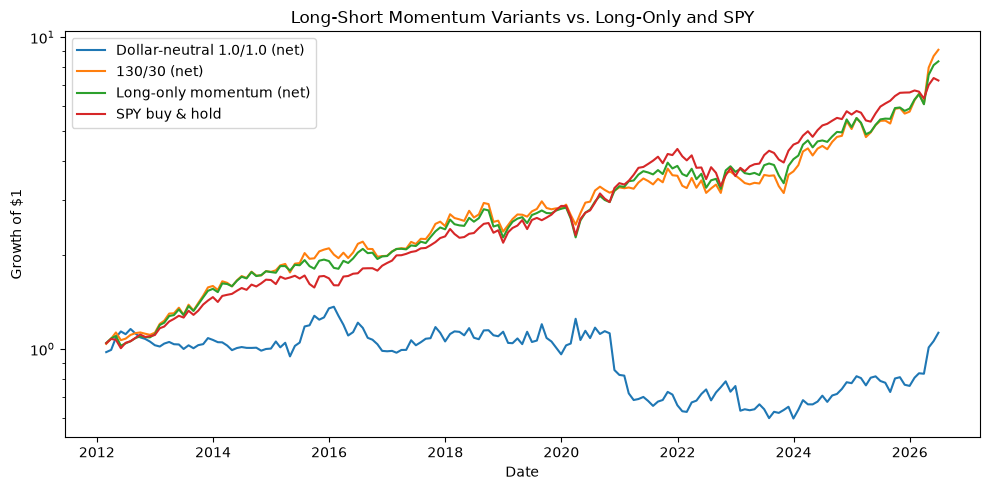

In [8]:
# All four equity curves on one (log-scale) chart. Log scale, as in notebook
# 01: growth compounds multiplicatively, and on a linear axis the early years
# of any several-fold grower squash into an unreadable flat line.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dollar_neutral_result.net_equity.index, dollar_neutral_result.net_equity,
        label="Dollar-neutral 1.0/1.0 (net)")
ax.plot(result_130_30.net_equity.index, result_130_30.net_equity,
        label="130/30 (net)")
ax.plot(long_only_result.net_equity.index, long_only_result.net_equity,
        label="Long-only momentum (net)")
ax.plot(benchmark_equity.index, benchmark_equity, label="SPY buy & hold")
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.set_title("Long-Short Momentum Variants vs. Long-Only and SPY")
ax.legend()
fig.tight_layout()

Five worst months, dollar-neutral (net):
2020-11-30    -23.7%
2023-01-31    -16.7%
2020-04-30    -14.5%
2021-02-28    -12.2%
2019-09-30     -9.7%
dtype: str

SPY's return in those same months, for context:
2020-11-30    10.9%
2023-01-31     6.3%
2020-04-30    12.7%
2021-02-28     2.8%
2019-09-30     1.9%
Name: SPY, dtype: str


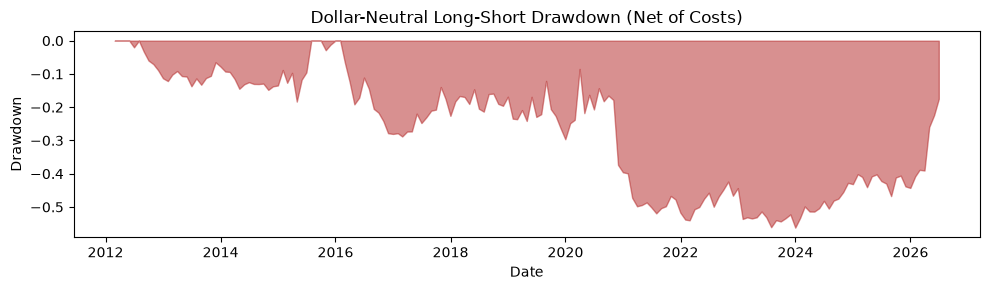

In [9]:
plot_drawdown(dollar_neutral_result.net_equity, title="Dollar-Neutral Long-Short Drawdown (Net of Costs)")

# The worst individual months, as a small momentum-crash check: the intro's
# warning is that the short book gets hurt when beaten-down names rally
# violently, so the strategy's worst months should cluster around sharp
# market rebounds/rotations rather than market falls.
print("Five worst months, dollar-neutral (net):")
print(dollar_neutral_result.net_returns.nsmallest(5).apply(lambda r: f"{r:.1%}"))
print("\nSPY's return in those same months, for context:")
print(benchmark_returns.reindex(dollar_neutral_result.net_returns.nsmallest(5).index).apply(lambda r: f"{r:.1%}"))

## 6. Robustness appendix: is this result fragile?

Same philosophy as notebook 01's appendix: the headline used pre-committed values, and this
grid reruns nearby, equally-reasonable *cost and structure* assumptions — both exposure pairs ×
borrow fee (0 / 30 / 100 bps, spanning "free to borrow" through "chronically expensive
inventory") × one-way trading cost (5 / 10 / 20 bps). We're looking for the qualitative
pattern, not the best cell: no parameter is being chosen from this table. (Signal-parameter
robustness — lookback and book size — was already established in notebook 01 and isn't
re-tuned here.)

In [10]:
robustness_rows = []

for long_exp, short_exp in [(1.0, 1.0), (1.3, 0.3)]:
    for borrow_bps in [0.0, 30.0, 100.0]:
        for cost_bps in [5.0, 10.0, 20.0]:
            variant_config = replace(
                DEFAULT_LONG_SHORT_CONFIG,
                long_exposure=long_exp, short_exposure=short_exp,
                borrow_fee_annual_bps=borrow_bps, one_way_cost_bps=cost_bps,
            )
            variant_result = run_long_short_backtest(variant_config)
            robustness_rows.append({
                "exposures": f"{long_exp:.1f}/{short_exp:.1f}",
                "borrow_fee_annual_bps": borrow_bps,
                "one_way_cost_bps": cost_bps,
                "net_CAGR": cagr(variant_result.net_equity),
                "net_Sharpe": sharpe_ratio(variant_result.net_returns),
                "net_MaxDD": max_drawdown(variant_result.net_equity),
            })

robustness_df = pd.DataFrame(robustness_rows)
robustness_df

$ANRZQ: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$BXLT: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$CPGX: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


$ALXN: possibly delisted; no timezone found


$CA: possibly delisted; no timezone found


...


19 Failed downloads:


['XL', 'WLTW']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


['TWC', 'WFM']: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)


['WIN', 'WCG', 'VIAB', 'WYND', 'WBA', 'UTX', 'TSS', 'XEC', 'WPX', 'X', 'TWTR', 'WRK', 'XLNX', 'VIAC', 'VAR']: possibly delisted; no timezone found


,exposures,borrow_fee_annual_bps,one_way_cost_bps,net_CAGR,net_Sharpe,net_MaxDD
0,1.0/1.0,0.0,5.0,0.019654,0.189571,-0.527519
1,1.0/1.0,0.0,10.0,0.013084,0.156231,-0.551334
2,1.0/1.0,0.0,20.0,0.000061,0.089586,-0.596407
3,1.0/1.0,30.0,5.0,0.016599,0.174335,-0.538180
4,1.0/1.0,30.0,10.0,0.010047,0.140998,-0.561976
5,1.0/1.0,30.0,20.0,-0.002940,0.074359,-0.605990
6,1.0/1.0,100.0,5.0,0.009503,0.138785,-0.563332
7,1.0/1.0,100.0,10.0,0.002994,0.105454,-0.585845
8,1.0/1.0,100.0,20.0,-0.009910,0.038829,-0.627483
9,1.3/0.3,0.0,5.0,0.170824,0.962183,-0.188906


In [11]:
for exposures, group in robustness_df.groupby("exposures"):
    print(f"{exposures}: net Sharpe ranges {group['net_Sharpe'].min():.2f} to {group['net_Sharpe'].max():.2f}, "
          f"net CAGR ranges {group['net_CAGR'].min():.1%} to {group['net_CAGR'].max():.1%}")
print("\nShare of all variants with positive net CAGR:", f"{(robustness_df['net_CAGR'] > 0).mean():.0%}")

1.0/1.0: net Sharpe ranges 0.04 to 0.19, net CAGR ranges -1.0% to 2.0%
1.3/0.3: net Sharpe ranges 0.86 to 0.96, net CAGR ranges 14.9% to 17.1%

Share of all variants with positive net CAGR: 89%


## 7. Limitations

Everything below is a real caveat on the numbers above, ordered roughly by how much it could
change them:

- **Short losses are theoretically unbounded, and monthly data hides the path.** A long
  position bottoms out at −100%; a shorted stock can rise without limit. Worse, this backtest
  only sees month-end prices: an intra-month spike in a shorted name that would have forced a
  real fund to buy back at the top (a margin call or broker recall) passes through invisibly
  if the price settled back by month-end. Real long-short implementations carry path risk this
  monthly simulation structurally cannot show.
- **The >300% vendor-glitch guard applies to the short book too — and could mask a genuine
  short blow-up.** The guard exists because the vendor demonstrably serves garbage (notebook
  01's CBE example), and whether a price series is trustworthy doesn't depend on which side of
  it we're positioned — so the same underlying-move exclusion is applied to both books rather
  than special-casing the shorts. The trade-off is stated plainly: if a shorted stock
  *genuinely* rose >300% in a month, that catastrophic loss would be excluded from the result
  instead of reported. This is exactly where the guard is most dangerous, which is why the
  exclusion counts are reported **per book** in section 3 — each short-book exclusion is one
  month where the reported number may flatter reality.
- **Missing forward prices bias the two books in opposite directions.** A mid-month delisting
  is dropped from that month's basket average (and counted, per book, in section 3). For the
  long book that's slightly *optimistic* — a delisting is often a collapse, i.e. a real loss
  that never counts. For the short book the same treatment is slightly *pessimistic*: a
  collapsing shorted stock is a *profit* the strategy never books. Same symmetric rule, honest
  in both directions, with both counts visible.
- **The borrow fee is one blended number — and momentum's short book is exactly where borrow
  gets expensive.** 30bps/year is a fair general-collateral rate for liquid large caps, but
  distressed, heavily-shorted names (the bottom of a momentum ranking, by construction) can
  cost hundreds of basis points to borrow. The robustness appendix spans 0–100bps; a truly
  per-name borrow model would need historical securities-lending data this project doesn't have.
- **No interest on short proceeds; no financing cost on the 130% long book.** Consistent with
  the project-wide 0% risk-free assumption. In reality a short seller earns a rebate on sale
  proceeds and a 130/30 fund pays financing on its extra 30% — near-zero rates make both small
  and partially offsetting; 2022+-era rates do not. Swapping in a real T-bill series is the
  same already-flagged upgrade as for the Sharpe ratio.
- **The famous momentum crashes are outside this window.** The catastrophic
  winners-minus-losers episodes (1932, 2009) predate 2012. This window contains only milder
  rotations (see the worst-months table in section 5), so the headline Sharpe describes the
  strategy in ordinary weather. The academic record says the true return distribution has a
  violently fat left tail that simply isn't sampled here.
- **A large-cap-only short book is a tamer version of the academic factor.** Bottom-50 of the
  S&P 500 is far more liquid and borrowable than the small-cap losers driving much of the
  published WML premium — which makes this backtest more *implementable* but likely to show a
  more muted long-short spread than the literature's headline numbers.
- **Everything notebook 01 already disclosed carries over unchanged**: community-maintained
  point-in-time constituents, a single blended transaction-cost figure, equal-weight
  full-rebalance mechanics, ~159 tickers with no Yahoo price data, and best-effort quality
  checks.

## 8. Conclusion

Phase 4 reuses Phase 1's signal, universe, costs, and evaluation code and changes exactly one
thing — holding both ends of the momentum ranking, at configurable exposures — so the
comparison between long-only, 130/30, and dollar-neutral momentum isolates what the *short
book* adds: its return contribution, its extra costs (turnover, borrow), its diversification
(correlation with SPY), and its distinct risks (unbounded losses, momentum crashes). The
robustness appendix shows how the picture shifts across cost and borrow assumptions rather
than presenting one tuned number.

**The honest reading of this window:** the 130/30 structure behaves like a modestly enhanced
long-only momentum fund — similar risk-adjusted return, market-like correlation, a little
extra CAGR from the short book. The dollar-neutral factor, by contrast, earned close to
nothing net of costs over 2012–2026, and its worst months land exactly where the
momentum-crash literature says they should: sharp market *rebounds* (late 2020, early 2023),
when the beaten-down names in the short book rallied violently while the market rose. That is
not a broken backtest — it's the well-documented post-2009 weakness of the academic momentum
factor showing up in independent data, and a backtester that can deliver that awkward result
is more trustworthy than one that never does.